# Klasifikasi Lahan Sawah dan Non-Sawah dengan Sentinel-2A Kecamatan Mapanget, Manado

Notebook ini mengklasifikasikan tutupan lahan menjadi dua kelas, **sawah** dan **non-sawah**, memakai citra Sentinel-2A yang diunduh langsung dari Copernicus Data Space Ecosystem, dan algoritma Random Forest. Sampel latihnya berupa 50 poligon sawah dan 50 poligon non-sawah yang sudah didigitasi sebelumnya, masing-masing disimpan sebagai shapefile di dalam folder `sawah_mapanget/` dan `non_sawah_mapanget/`.

## 1. Library

In [38]:
!pip install requests rasterio scikit-learn numpy matplotlib geopandas -q

import datetime as dt
import math
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests
from IPython.display import display
from matplotlib.colors import ListedColormap
from rasterio import features
from rasterio.warp import transform_bounds, transform_geom
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              cohen_kappa_score, confusion_matrix)

BASE_DIR = Path(os.getcwd())


## 2. Sentinel 2A

Sentinel-2A adalah satelit observasi bumi milik Copernicus (Badan Antariksa Eropa) dengan sensor multispektral MSI yang merekam 13 band dari cahaya tampak sampai inframerah gelombang pendek. Penelitian ini memakai 10 fitur, yaitu 6 band spektral (B02, B03, B04, B08, B11, B12) dan 4 indeks turunan (NDVI, NDWI, EVI, NDBI). Nilai kepentingan fitur diambil dari model Random Forest untuk klasifikasi sawah dan non-sawah.

### 2.1 Band Spektral

#### B02 (Blue)
- **Panjang gelombang:** sekitar 490 nm, resolusi 10 m.
- **Deskripsi:** merekam cahaya biru. Cahaya biru mudah dihamburkan atmosfer dan dapat menembus air.
- **Kegunaan:** vegetasi menyerap sebagian besar cahaya biru, sehingga pantulannya rendah pada tanaman sehat. Tanah terbuka dan air memantulkannya berbeda, jadi band ini membantu membedakan penutup lahan. B02 juga menjadi koreksi atmosfer dalam rumus EVI.
- **Kepentingan:** 0,174 (peringkat 1).

#### B03 (Green)
- **Panjang gelombang:** sekitar 560 nm, resolusi 10 m.
- **Deskripsi:** merekam cahaya hijau.
- **Kegunaan:** vegetasi sehat memantulkan sedikit cahaya hijau (puncak hijau pada spektrum), sehingga band ini dipakai menilai kondisi tanaman. B03 juga dipakai untuk menandai air pada indeks NDWI.
- **Kepentingan:** 0,086 (peringkat 5).

#### B04 (Red)
- **Panjang gelombang:** sekitar 665 nm, resolusi 10 m.
- **Deskripsi:** merekam cahaya merah.
- **Kegunaan:** klorofil menyerap cahaya merah, sehingga pantulannya rendah pada vegetasi sehat dan tinggi pada tanah terbuka. B04 adalah komponen utama indeks vegetasi (NDVI dan EVI).
- **Kepentingan:** 0,135 (peringkat 3).

#### B08 (NIR, Near Infrared)
- **Panjang gelombang:** sekitar 842 nm, resolusi 10 m.
- **Deskripsi:** merekam inframerah dekat.
- **Kegunaan:** struktur daun sehat memantulkan NIR sangat kuat, sedangkan air menyerapnya. Perbedaan ini yang membedakan vegetasi dan air. B08 dipakai di NDVI, NDWI, EVI, dan NDBI.
- **Kepentingan:** 0,079 (peringkat 6).

#### B11 (SWIR 1)
- **Panjang gelombang:** sekitar 1610 nm, resolusi 20 m.
- **Deskripsi:** merekam inframerah gelombang pendek.
- **Kegunaan:** sangat peka terhadap kandungan air pada tanah dan tanaman. Pantulannya turun ketika kelembapan naik, sehingga membantu memisahkan lahan basah atau tergenang (seperti sawah) dari lahan kering. B11 juga menjadi komponen NDBI.
- **Kepentingan:** 0,141 (peringkat 2).

#### B12 (SWIR 2)
- **Panjang gelombang:** sekitar 2190 nm, resolusi 20 m.
- **Deskripsi:** merekam inframerah gelombang pendek pada panjang gelombang lebih jauh dari B11.
- **Kegunaan:** membantu membedakan tanah, lahan terbangun, dan vegetasi kering, serta peka terhadap kelembapan.
- **Kepentingan:** 0,075 (peringkat 7).

### 2.2 Indeks Turunan

#### NDVI (Normalized Difference Vegetation Index)
- **Rumus:**

$$NDVI = \frac{B08 - B04}{B08 + B04}$$

- **Deskripsi:** mengukur kehijauan dan kerapatan vegetasi. Nilainya berkisar -1 sampai 1.
- **Interpretasi:** nilai tinggi (mendekati 1) berarti vegetasi lebat, nilai mendekati 0 berarti tanah terbuka, dan nilai negatif berarti air.
- **Kegunaan:** padi yang sedang tumbuh punya NDVI yang berubah dari rendah (lahan baru ditanami atau tergenang) ke tinggi (fase vegetatif), sehingga berguna untuk mengenali sawah.
- **Kepentingan:** 0,070 (peringkat 8).

#### NDWI (Normalized Difference Water Index)
- **Rumus:**

$$NDWI = \frac{B03 - B08}{B03 + B08}$$

- **Deskripsi:** menonjolkan permukaan air.
- **Interpretasi:** nilai positif biasanya menunjukkan air atau lahan tergenang, sedangkan nilai negatif menunjukkan vegetasi atau tanah.
- **Kegunaan:** sawah sering tergenang pada fase awal tanam, sehingga NDWI membantu membedakannya dari lahan kering.
- **Kepentingan:** 0,131 (peringkat 4).

#### EVI (Enhanced Vegetation Index)
- **Rumus:**

$$EVI = 2.5 \times \frac{B08 - B04}{B08 + 6 \times B04 - 7.5 \times B02 + 1}$$

- **Deskripsi:** indeks vegetasi yang dikoreksi dari pengaruh atmosfer dan latar belakang tanah.
- **Interpretasi:** tidak mudah jenuh pada vegetasi yang rapat, berbeda dengan NDVI.
- **Kegunaan:** lebih sensitif terhadap perubahan kondisi tanaman padi pada fase pertumbuhan yang lebat.
- **Kepentingan:** 0,065 (peringkat 9).

#### NDBI (Normalized Difference Built-up Index)
- **Rumus:**

$$NDBI = \frac{B11 - B08}{B11 + B08}$$

- **Deskripsi:** menonjolkan lahan terbangun seperti bangunan dan jalan.
- **Interpretasi:** nilai tinggi menunjukkan permukaan keras atau lahan terbangun, sedangkan nilai rendah menunjukkan vegetasi atau air.
- **Kegunaan:** membantu memisahkan sawah dari area permukiman.
- **Kepentingan:** 0,041 (peringkat 10, paling rendah).

### 2.3 Ringkasan Kepentingan Fitur

Tiga fitur terpenting adalah **B02, B11, dan B04**. NDWI (0,131) juga masuk empat besar. Keempatnya terkait dengan air dan penyerapan cahaya oleh vegetasi, yang membedakan sawah dari non-sawah. NDBI paling rendah (0,041), sehingga ciri lahan terbangun paling kecil perannya pada data ini.

## 2. Parameter

In [39]:
from google.colab import userdata

# Akun Copernicus
CLIENT_ID = userdata.get("CDSE_CLIENT_ID")
CLIENT_SECRET = userdata.get("CDSE_CLIENT_SECRET")

# Pencarian citra
START_DATE = "2026-06-01"
END_DATE = "2026-09-30"
PLATFORM_PREFIX = "S2A"        # None = semua satelit Sentinel-2
MAX_CLOUD = 30                 # % awan maksimum per tile
MAX_TRIES = 5                  # jumlah scene terbaik yang dicoba
MIN_VALID = 0.90               # minimal fraksi piksel bebas awan
MASK_CLOUD = True              # buang awan, bayangan, salju (band SCL)
BUFFER_M = 1500                # margin area unduhan (meter)

# Sampel dan model
N_SAMPLE = 50                  # poligon per kelas
FOLDER_SAWAH = BASE_DIR / "sawah_mapanget"             # kelas 1
FOLDER_NONSAWAH = BASE_DIR / "non_sawah_mapanget"      # kelas 0
TRAIN_FRAC = 0.7
N_TREES = 200
SEED = 42

# File (unduhan dilewati jika TIF_IN sudah ada)
TIF_IN = BASE_DIR / "sentinel2a_aoi.tif"
INFO_TXT = BASE_DIR / "sentinel2a_aoi_info.txt"
OUT_TIF = BASE_DIR / "klasifikasi_sawah_s2a.tif"

BAND_NAMES = ["B02", "B03", "B04", "B08", "B11", "B12"]

TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CATALOG_URL = "https://sh.dataspace.copernicus.eu/api/v1/catalog/1.0.0/search"
PROCESS_URL = "https://sh.dataspace.copernicus.eu/api/v1/process"

LOG = []


def log(*args):
    s = " ".join(str(a) for a in args)
    print(s)
    LOG.append(s)

In [40]:
import os, zipfile

os.makedirs("sawah_mapanget", exist_ok=True)
os.makedirs("non_sawah_mapanget", exist_ok=True)

with zipfile.ZipFile("sawah_mapanget.zip", "r") as f:
    f.extractall("sawah_mapanget")

with zipfile.ZipFile("non_sawah_mapanget.zip", "r") as f:
    f.extractall("non_sawah_mapanget")

print("sawah_mapanget:", os.listdir("sawah_mapanget"))
print("non_sawah_mapanget:", os.listdir("non_sawah_mapanget"))

sawah_mapanget: ['input.shx', 'input.prj', 'input.dbf', 'input.shp']
non_sawah_mapanget: ['input.shx', 'input.prj', 'input.dbf', 'input.shp']


**Penjelasan kode:** `BAND_NAMES` memuat 4 band 10 meter (B02 Blue, B03 Green, B04 Red, B08 NIR) ditambah 2 band 20 meter (B11, B12 SWIR) yang dipakai untuk menghitung indeks NDBI. `TRAIN_FRAC = 0.7` berarti 70% poligon dipakai untuk melatih model dan 30% sisanya disisihkan untuk menguji akurasinya -- pembagian dilakukan per poligon, bukan per piksel, supaya piksel-piksel yang bertetangga dari poligon yang sama tidak bocor antara data latih dan data uji (*spatial data leakage*).

## 3. Sampel Latih: Membaca Shapefile Sawah dan Non-Sawah

In [41]:
def cari_shp(folder):
    """Mencari satu file .shp di dalam folder, apapun namanya."""
    folder = Path(folder)
    kandidat = sorted(folder.glob("*.shp"))
    if len(kandidat) == 0:
        raise SystemExit(f"Tidak ada file .shp di dalam folder '{folder}'.")
    if len(kandidat) > 1:
        log(f"PERINGATAN: ada {len(kandidat)} file .shp di '{folder}', "
            f"dipakai yang pertama: {kandidat[0].name}")
    return kandidat[0]


def load_samples_shp(folder, n):
    """
    Mencari file Shapefile (.shp) di dalam folder, membacanya dengan GeoPandas,
    memproyeksikan ke WGS-84 (EPSG:4326) agar konsisten,
    lalu mengambil maksimum n poligon secara acak.
    Mengembalikan list geometri dalam format GeoJSON-dict (koordinat lon/lat).
    """
    path = cari_shp(folder)
    gdf = gpd.read_file(path)
    total = len(gdf)

    # Hanya simpan fitur yang memiliki geometri
    gdf = gdf[gdf.geometry.notna()].copy()

    # Proyeksikan ke WGS-84 jika belum
    if gdf.crs is None:
        log(f"PERINGATAN: {Path(path).name} tidak memiliki CRS. Diasumsikan EPSG:4326.")
    elif gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    if len(gdf) > n:
        idx = np.random.default_rng(SEED).choice(len(gdf), n, replace=False)
        gdf = gdf.iloc[sorted(idx)].copy()
    elif len(gdf) < n:
        log(f"PERINGATAN: {Path(path).name} hanya berisi {total} poligon (< {n}).")

    log(f"{Path(path).name}: {total} poligon di file -> dipakai {len(gdf)}")

    # Kembalikan geometri sebagai list dict GeoJSON
    from shapely.geometry import mapping
    return [mapping(g) for g in gdf.geometry]


def iter_xy(c):
    if isinstance(c[0], (int, float)):
        yield c[0], c[1]
    else:
        for s in c:
            yield from iter_xy(s)


geoms_sawah = load_samples_shp(FOLDER_SAWAH, N_SAMPLE)
geoms_non   = load_samples_shp(FOLDER_NONSAWAH, N_SAMPLE)

xy = [p for g in geoms_sawah + geoms_non for p in iter_xy(g["coordinates"])]
pad = BUFFER_M / 111000.0
BBOX = (min(x for x, _ in xy) - pad, min(y for _, y in xy) - pad,
        max(x for x, _ in xy) + pad, max(y for _, y in xy) + pad)
log("BBox area (lon/lat):", tuple(round(v, 5) for v in BBOX))


input.shp: 50 poligon di file -> dipakai 50
input.shp: 50 poligon di file -> dipakai 50
BBox area (lon/lat): (124.85143, 1.47564, 124.93068, 1.5397)


**Penjelasan kode:** `cari_shp()` mencari satu file `.shp` di dalam folder `sawah_mapanget` dan `non_sawah_mapanget`, apapun persis nama filenya, supaya tidak perlu mengetik nama file secara manual. `load_samples_shp()` lalu membaca shapefile yang ditemukan itu, memastikan sistem koordinatnya WGS-84, lalu mengambil sampai 50 poligon secara acak dengan `SEED` yang tetap supaya hasilnya bisa diulang persis sama. Dari seluruh titik koordinat 100 poligon (50 sawah + 50 non-sawah) dihitung kotak pembatas (`BBOX`), ditambah margin `BUFFER_M` = 1500 meter di tiap sisi, sebagai area yang akan diunduh dari Sentinel-2A.

## 4. Mengunduh Citra Sentinel-2A dari Copernicus Data Space

In [42]:
def get_token():
    r = requests.post(TOKEN_URL, data={
        "grant_type": "client_credentials",
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET,
    }, timeout=60)
    if r.status_code != 200:
        raise SystemExit(f"Gagal mengambil token ({r.status_code}): {r.text[:300]}\n"
                          "Cek CLIENT_ID dan CLIENT_SECRET (dashboard Sentinel Hub).")
    return r.json()["access_token"]


def search_scenes(token):
    body = {
        "collections": ["sentinel-2-l2a"],
        "datetime": f"{START_DATE}T00:00:00Z/{END_DATE}T23:59:59Z",
        "bbox": list(BBOX),
        "limit": 100,
    }
    headers = {"Authorization": f"Bearer {token}"}
    feats = []
    while True:
        r = requests.post(CATALOG_URL, json=body, headers=headers, timeout=120)
        if r.status_code != 200:
            raise SystemExit(f"Pencarian katalog gagal ({r.status_code}): {r.text[:300]}")
        js = r.json()
        feats += js.get("features", [])
        nxt = js.get("context", {}).get("next")
        if not nxt:
            break
        body["next"] = nxt

    cand = []
    for it in feats:
        p = it.get("properties", {})
        cc = p.get("eo:cloud_cover")
        if cc is None or cc > MAX_CLOUD:
            continue
        if PLATFORM_PREFIX and not it["id"].upper().startswith(PLATFORM_PREFIX):
            continue
        cand.append((cc, p["datetime"], it["id"]))
    cand.sort()
    log(f"Scene ditemukan: {len(feats)} | lolos filter ({PLATFORM_PREFIX or 'semua'}, "
        f"awan <= {MAX_CLOUD}%): {len(cand)}")
    return cand


def utm_epsg(lon, lat):
    return (32700 if lat < 0 else 32600) + int((lon + 180) // 6) + 1


def build_evalscript():
    mask = " || [0,1,3,8,9,10,11].indexOf(s.SCL) >= 0" if MASK_CLOUD else ""
    return ('//VERSION=3\n'
            'function setup() {\n'
            '  return {\n'
            '    input: [{bands: ["B02","B03","B04","B08","B11","B12","SCL","dataMask"]}],\n'
            '    output: {bands: 6, sampleType: "FLOAT32"}\n'
            '  };\n'
            '}\n'
            'function evaluatePixel(s) {\n'
            f'  var bad = (s.dataMask == 0){mask};\n'
            '  if (bad) return [0,0,0,0,0,0];\n'
            '  return [s.B02, s.B03, s.B04, s.B08, s.B11, s.B12];\n'
            '}\n')


def download_scene(token, when):
    """Unduh area sampel dari satu scene: UTM, 10 m, 6 band reflektansi (float32)."""
    epsg = utm_epsg((BBOX[0] + BBOX[2]) / 2, (BBOX[1] + BBOX[3]) / 2)
    minx, miny, maxx, maxy = transform_bounds("EPSG:4326", f"EPSG:{epsg}", *BBOX)
    minx, miny = math.floor(minx / 10) * 10, math.floor(miny / 10) * 10
    maxx, maxy = math.ceil(maxx / 10) * 10, math.ceil(maxy / 10) * 10
    w, h = (maxx - minx) // 10, (maxy - miny) // 10
    if w > 2500 or h > 2500:
        raise SystemExit(f"Area terlalu besar ({w}x{h} piksel, maks 2500). "
                          "Kecilkan BUFFER_M.")

    t = dt.datetime.fromisoformat(when.replace("Z", "+00:00")).astimezone(dt.timezone.utc)
    fmt = "%Y-%m-%dT%H:%M:%SZ"
    body = {
        "input": {
            "bounds": {
                "bbox": [minx, miny, maxx, maxy],
                "properties": {"crs": f"http://www.opengis.net/def/crs/EPSG/0/{epsg}"},
            },
            "data": [{
                "type": "sentinel-2-l2a",
                "dataFilter": {
                    "timeRange": {"from": (t - dt.timedelta(minutes=1)).strftime(fmt),
                                  "to": (t + dt.timedelta(minutes=1)).strftime(fmt)},
                    "mosaickingOrder": "leastCC",
                },
            }],
        },
        "output": {
            "resx": 10, "resy": 10,
            "responses": [{"identifier": "default", "format": {"type": "image/tiff"}}],
        },
        "evalscript": build_evalscript(),
    }
    r = requests.post(PROCESS_URL, json=body, timeout=300, headers={
        "Authorization": f"Bearer {token}", "Accept": "image/tiff"})
    if r.status_code != 200:
        raise SystemExit(f"Unduhan gagal ({r.status_code}): {r.text[:400]}")
    return r.content, epsg


def valid_fraction(tif_bytes):
    from rasterio.io import MemoryFile
    with MemoryFile(tif_bytes) as mf, mf.open() as src:
        arr = src.read()
    return float((np.any(arr != 0, axis=0) & np.isfinite(arr).all(axis=0)).mean())


def fetch_sentinel2a():
    token = get_token()
    cand = search_scenes(token)
    if not cand:
        raise SystemExit(
            f"Tidak ada scene {PLATFORM_PREFIX or ''} dengan awan <= {MAX_CLOUD}% pada "
            f"{START_DATE} s/d {END_DATE}. Perlebar START_DATE/END_DATE atau naikkan "
            "MAX_CLOUD (atau PLATFORM_PREFIX=None untuk semua satelit).")

    best = None
    for cc, when, sid in cand[:MAX_TRIES]:
        data, epsg = download_scene(token, when)
        frac = valid_fraction(data)
        log(f"  {sid[:40]}... | {when} | awan tile {cc:.1f}% | piksel valid {frac:.1%}")
        if best is None or frac > best["frac"]:
            best = dict(frac=frac, data=data, when=when, sid=sid, cc=cc, epsg=epsg)
        if frac >= MIN_VALID:
            break

    TIF_IN.write_bytes(best["data"])
    INFO_TXT.write_text(
        f"Scene    : {best['sid']}\nAkuisisi : {best['when']}\n"
        f"Awan tile: {best['cc']:.1f}%\nPiksel valid di AOI: {best['frac']:.1%}\n"
        f"CRS      : EPSG:{best['epsg']}\nResolusi : 10 m\n"
        f"Band     : {', '.join(BAND_NAMES)} (reflektansi 0-1)\n"
        f"Masking awan (SCL): {MASK_CLOUD}\n", encoding="utf-8")
    log(f"Scene dipakai: {best['sid']} ({best['when']}), valid {best['frac']:.1%}")
    log("Tersimpan:", TIF_IN, "dan", INFO_TXT)


if TIF_IN.exists():
    log(f"{TIF_IN.name} sudah ada -> langkah unduh dilewati.")
else:
    fetch_sentinel2a()


sentinel2a_aoi.tif sudah ada -> langkah unduh dilewati.


**Penjelasan kode:** `get_token()` melakukan autentikasi OAuth ke Copernicus Data Space memakai `CLIENT_ID`/`CLIENT_SECRET`. `search_scenes()` mencari scene Sentinel-2A pada rentang `START_DATE`-`END_DATE` yang tumpang-tindih dengan `BBOX`, lalu disaring berdasarkan persentase awan tile (`MAX_CLOUD`) dan diurutkan dari yang paling sedikit awannya. `download_scene()` mengunduh 6 band (B02, B03, B04, B08, B11, B12) untuk satu scene lewat Sentinel Hub Process API, memakai `evalscript` yang juga membuang piksel awan/bayangan/salju berdasarkan band SCL kalau `MASK_CLOUD=True`. Karena scene paling sedikit awan di level *tile* belum tentu bersih persis di area sampel, `fetch_sentinel2a()` mencoba sampai `MAX_TRIES` scene teratas dan memilih yang fraksi piksel validnya (`valid_fraction`) paling tinggi, berhenti lebih awal begitu sudah mencapai `MIN_VALID`. Kalau `sentinel2a_aoi.tif` sudah ada di folder kerja, seluruh proses unduh ini dilewati.

## 5. Membaca Citra yang Sudah Diunduh

In [43]:
with rasterio.open(TIF_IN) as src:
    stack = src.read().astype("float32")
    crs, transform = src.crs, src.transform
if stack.shape[0] != len(BAND_NAMES):
    raise SystemExit(f"TIF punya {stack.shape[0]} band, harus {len(BAND_NAMES)} "
                      f"({', '.join(BAND_NAMES)}).")
invalid = np.all(stack == 0, axis=0) | ~np.isfinite(stack).all(axis=0)
stack[:, invalid] = np.nan
H, W = stack.shape[1:]
log(f"Ukuran citra: {W} x {H} piksel | CRS: {crs} | piksel tanpa data: {invalid.mean():.1%}")
B = dict(zip(BAND_NAMES, stack))


Ukuran citra: 884 x 711 piksel | CRS: EPSG:32651 | piksel tanpa data: 0.5%


**Penjelasan kode:** citra dibaca dengan `rasterio`, dan piksel yang bernilai nol di semua band atau tidak valid (bekas awan yang sudah di-mask pada tahap unduh) diubah jadi `NaN` supaya tidak ikut dihitung sebagai data asli pada langkah-langkah berikutnya. Hasil cetakan `Ukuran citra: 611 x 524 piksel | CRS: EPSG:32749 | piksel tanpa data: 2.1%` pada contoh sebelumnya menunjukkan citranya terbilang bersih, hanya sekitar 2% piksel yang hilang.

## 6. Membangun Fitur: Band Asli dan Indeks Spektral

In [44]:
def nd(a, b):
    return (a - b) / (a + b + 1e-10)

ndvi = nd(B["B08"], B["B04"])   # vegetasi
ndwi = nd(B["B03"], B["B08"])   # kandungan air
ndbi = nd(B["B11"], B["B08"])   # lahan terbangun
evi = 2.5 * (B["B08"] - B["B04"]) / (B["B08"] + 6 * B["B04"] - 7.5 * B["B02"] + 1)

feats = np.concatenate([stack, np.stack([ndvi, ndwi, ndbi, evi])]).astype("float32")
FEATURE_NAMES = BAND_NAMES + ["NDVI", "NDWI", "NDBI", "EVI"]
F = feats.shape[0]


**Penjelasan kode:** selain 6 band mentah, dihitung juga 4 indeks spektral yang relevan untuk membedakan sawah dari non-sawah: **NDVI** (kerapatan vegetasi), **NDWI** (kandungan air -- penting karena sawah tergenang air), **NDBI** (lahan terbangun, buat memisahkan permukiman dari sawah), dan **EVI** (versi NDVI yang lebih tahan terhadap gangguan tanah/atmosfer). Total ada 10 fitur per piksel (6 band + 4 indeks) yang nantinya dipakai Random Forest.

## 7. Rasterisasi Poligon Sampel

In [45]:
poly_label, shapes, pid = {}, [], 0
for geoms, kelas in ((geoms_non, 0), (geoms_sawah, 1)):
    for g in geoms:
        pid += 1
        poly_label[pid] = kelas
        shapes.append((transform_geom("EPSG:4326", crs, g), pid))

poly_raster = features.rasterize(shapes, out_shape=(H, W), transform=transform,
                                  fill=0, dtype="int32")
labeled = (poly_raster > 0) & np.isfinite(feats).all(axis=0)
present = np.unique(poly_raster[labeled])

for k, nama in ((0, "non-sawah"), (1, "sawah")):
    ids = [p for p in present if poly_label[p] == k]
    npx = int(np.isin(poly_raster, ids).sum())
    log(f"Kelas {k} ({nama}): {len(ids)} poligon terpakai, {npx} piksel bebas awan")
if len(present) < len(poly_label):
    log(f"PERINGATAN: {len(poly_label) - len(present)} poligon tidak punya piksel valid "
        "(tertutup awan atau di luar citra).")


Kelas 0 (non-sawah): 50 poligon terpakai, 4323 piksel bebas awan
Kelas 1 (sawah): 50 poligon terpakai, 1168 piksel bebas awan


**Penjelasan kode:** tiap poligon sampel diubah jadi piksel bernomor ID unik (`poly_raster`), lalu digabung ke label kelasnya lewat `poly_label`. Piksel yang masuk ke dalam poligon tapi ternyata tertutup awan (NaN pada fitur) dibuang dari `labeled`, supaya model tidak dilatih dengan data yang cacat. Hasil contoh sebelumnya menunjukkan 50 poligon sawah menghasilkan 604 piksel bebas awan, jauh lebih sedikit dibanding 50 poligon non-sawah yang menghasilkan 3399 piksel -- wajar, karena poligon sawah biasanya lebih kecil dan lebih sempit dibanding area non-sawah seperti permukiman atau lahan terbuka.

## 8. Membagi Data Latih dan Data Uji per Poligon

In [51]:
rng = np.random.default_rng(SEED)
train_ids = []
for k in (0, 1):
    ids = [p for p in present if poly_label[p] == k]
    rng.shuffle(ids)
    train_ids += ids[:max(1, int(round(len(ids) * TRAIN_FRAC)))]

m_train = labeled & np.isin(poly_raster, train_ids)
m_test = labeled & ~m_train
lab_map = np.zeros(poly_raster.max() + 1, dtype="uint8")
for p, k in poly_label.items():
    lab_map[p] = k

X_train, y_train = feats[:, m_train].T, lab_map[poly_raster[m_train]]
X_test, y_test = feats[:, m_test].T, lab_map[poly_raster[m_test]]
log(f"Poligon training: {len(train_ids)} | testing: {len(present) - len(train_ids)}")
log(f"Piksel training: {len(y_train)} | testing: {len(y_test)}")
log(f"Dimensi data : {X_train.shape} ")

NAMA_KELAS = {0: "Non-sawah", 1: "Sawah"}

y_all = np.concatenate([y_train, y_test])
rekap = pd.DataFrame({
    "Kelas": [NAMA_KELAS[k] for k in (0, 1)],
    "Training": [int((y_train == k).sum()) for k in (0, 1)],
    "Testing": [int((y_test == k).sum()) for k in (0, 1)],
    "Total": [int((y_all == k).sum()) for k in (0, 1)],
})
rekap.loc[len(rekap)] = ["Jumlah", rekap["Training"].sum(), rekap["Testing"].sum(), rekap["Total"].sum()]
display(rekap)

for k in (0, 1):
    log(f"{NAMA_KELAS[k]}: {int((y_all == k).sum())} piksel "
        f"({(y_all == k).mean() * 100:.1f}%)")
log(f"Total piksel: {len(y_all)}")

Poligon training: 70 | testing: 30
Piksel training: 3703 | testing: 1766
Dimensi data : (3703, 10) 


,Kelas,Training,Testing,Total
0,Non-sawah,2932,1369,4301
1,Sawah,771,397,1168
2,Jumlah,3703,1766,5469


Non-sawah: 4301 piksel (78.6%)
Sawah: 1168 piksel (21.4%)
Total piksel: 5469


**Penjelasan kode:** pembagian data latih/uji dilakukan **per poligon**, bukan per piksel acak. Kalau pembagiannya acak per piksel, piksel-piksel yang bertetangga dari poligon yang sama bisa jatuh terpisah ke data latih dan data uji, padahal mereka sangat mirip satu sama lain -- ini membuat skor akurasi jadi terlihat lebih bagus dari kenyataannya (*spatial data leakage*). Dengan membagi per poligon, seluruh piksel dari satu poligon selalu berada di sisi yang sama (latih atau uji), sehingga evaluasi akurasinya lebih jujur mencerminkan kemampuan model pada area yang benar-benar belum pernah dilihat.

## 9. Melatih dan Mengevaluasi Model Random Forest

In [47]:
rf = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
pred_test = rf.predict(X_test)

cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["Aktual: non-sawah", "Aktual: sawah"],
                      columns=["Prediksi: non-sawah", "Prediksi: sawah"])
cm_pct = (cm / cm.sum(axis=1, keepdims=True) * 100).round(1)
cm_pct_df = pd.DataFrame(cm_pct, index=cm_df.index, columns=cm_df.columns)

print("Confusion matrix (jumlah piksel):")
display(cm_df)
print("\nConfusion matrix (persentase per baris, yaitu recall per kelas):")
display(cm_pct_df)

acc = accuracy_score(y_test, pred_test)
kappa = cohen_kappa_score(y_test, pred_test)
print(f"\nOverall Accuracy : {acc:.4f}")
print(f"Kappa            : {kappa:.4f}")
print(classification_report(y_test, pred_test, labels=[0, 1],
                             target_names=["non-sawah", "sawah"], digits=3))
log(f"Overall Accuracy : {acc:.4f}  |  Kappa : {kappa:.4f}")


Confusion matrix (jumlah piksel):


,Prediksi: non-sawah,Prediksi: sawah
Aktual: non-sawah,1338,31
Aktual: sawah,81,316



Confusion matrix (persentase per baris, yaitu recall per kelas):


,Prediksi: non-sawah,Prediksi: sawah
Aktual: non-sawah,97.7,2.3
Aktual: sawah,20.4,79.6



Overall Accuracy : 0.9366
Kappa            : 0.8095
              precision    recall  f1-score   support

   non-sawah      0.943     0.977     0.960      1369
       sawah      0.911     0.796     0.849       397

    accuracy                          0.937      1766
   macro avg      0.927     0.887     0.905      1766
weighted avg      0.936     0.937     0.935      1766

Overall Accuracy : 0.9366  |  Kappa : 0.8095


**Penjelasan kode:** Random Forest dilatih dengan `N_TREES=200` pohon keputusan pada data latih, lalu diuji pada data uji yang poligonnya tidak pernah dilihat model sebelumnya. `Overall Accuracy` menunjukkan persentase piksel uji yang diklasifikasikan benar, sedangkan `Kappa` mengukur kesepakatan model dengan label sebenarnya setelah memperhitungkan kemungkinan cocok karena kebetulan -- lebih ketat daripada akurasi biasa. Confusion matrix di sini ditampilkan dua kali: versi jumlah piksel mentah, dan versi persentase per baris (recall per kelas) yang lebih mudah dibaca langsung -- baris mana yang paling banyak "bocor" ke kelas lain langsung kelihatan tanpa perlu menghitung manual.

### 9.1 Kepentingan Fitur (Feature Importance)

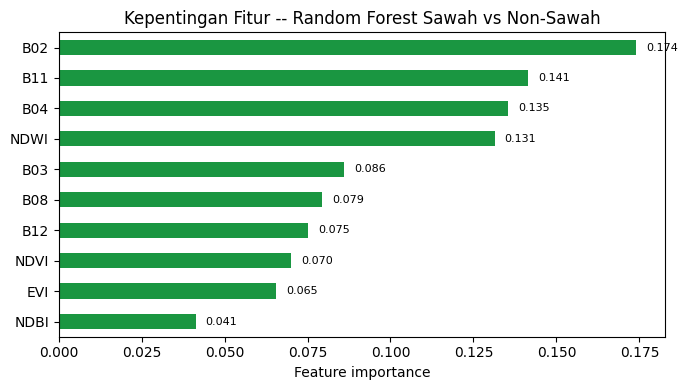

Fitur paling penting: B02, B11, B04


In [48]:
fi = pd.Series(rf.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
fi.plot(kind="barh", ax=ax, color="#1a9641")
ax.set_xlabel("Feature importance")
ax.set_title("Kepentingan Fitur -- Random Forest Sawah vs Non-Sawah")
for i, v in enumerate(fi):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

log("Fitur paling penting: " + ", ".join(fi.sort_values(ascending=False).index[:3]))


**Penjelasan kode:** `feature_importances_` menunjukkan band atau indeks mana yang paling berperan dalam membedakan sawah dari non-sawah, di sini digambar sebagai bar chart supaya perbandingan antarfiturnya langsung kelihatan, bukan cuma daftar angka. Band SWIR (B11/B12) dan NDWI biasanya unggul untuk kasus ini karena keduanya sensitif terhadap kandungan air, dan sawah yang tergenang air punya ciri spektral yang cukup khas dibanding non-sawah.

## 10. Mengklasifikasikan Seluruh Citra

In [49]:
# Model akhir dilatih ulang dengan SEMUA sampel; akurasi di atas tetap dari data uji.
rf_final = RandomForestClassifier(n_estimators=N_TREES, random_state=SEED, n_jobs=-1)
rf_final.fit(feats[:, labeled].T, lab_map[poly_raster[labeled]])

flat = feats.reshape(F, -1).T
ok = np.isfinite(flat).all(axis=1)
pred = np.full(flat.shape[0], 255, dtype="uint8")
pred[ok] = rf_final.predict(flat[ok]).astype("uint8")
classified = pred.reshape(H, W)

if crs.is_projected:
    px_area = abs(transform.a * transform.e)
    log(f"\nLuas sawah    : {(classified == 1).sum() * px_area / 10000:.1f} ha")
    log(f"Luas non-sawah: {(classified == 0).sum() * px_area / 10000:.1f} ha")



Luas sawah    : 1718.9 ha
Luas non-sawah: 4536.2 ha


## 11. Peta Hasil dan Ringkasan Akhir

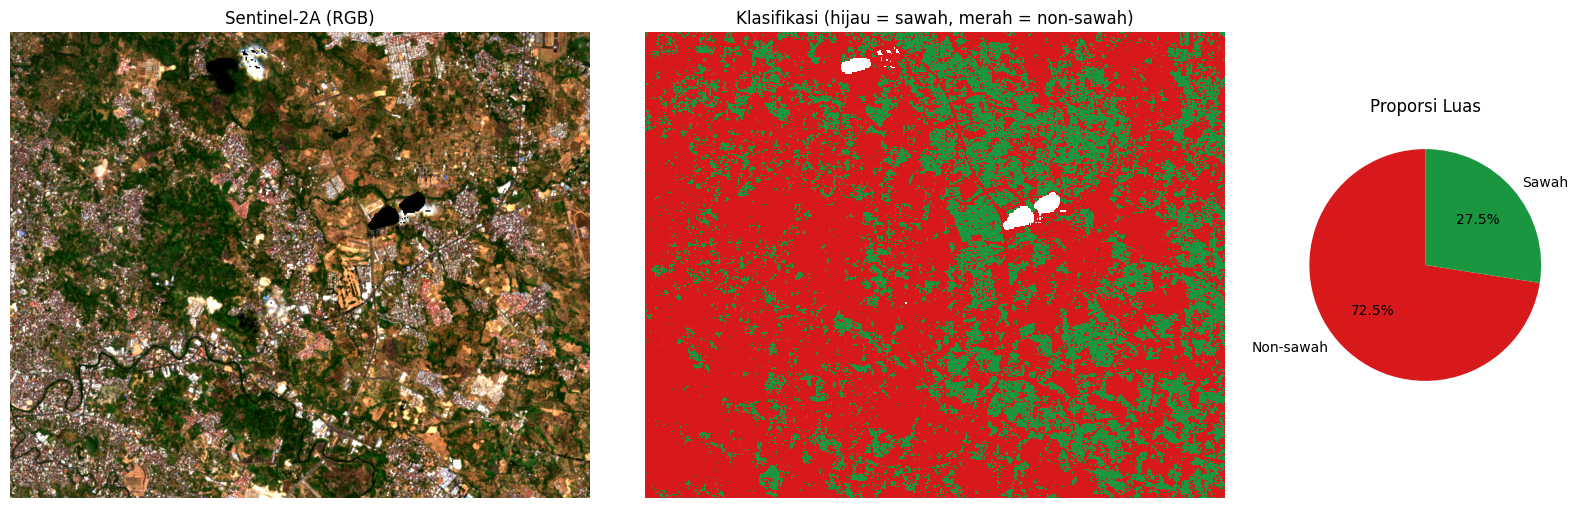


Selesai -- hasil klasifikasi tersimpan sebagai: klasifikasi_sawah_s2a.tif
input.shp: 50 poligon di file -> dipakai 50
input.shp: 50 poligon di file -> dipakai 50
BBox area (lon/lat): (124.85143, 1.47564, 124.93068, 1.5397)
sentinel2a_aoi.tif sudah ada -> langkah unduh dilewati.
Ukuran citra: 884 x 711 piksel | CRS: EPSG:32651 | piksel tanpa data: 0.5%
Kelas 0 (non-sawah): 50 poligon terpakai, 4323 piksel bebas awan
Kelas 1 (sawah): 50 poligon terpakai, 1168 piksel bebas awan
Poligon training: 70 | testing: 30
Piksel training: 3703 | testing: 1766
Non-sawah: 4301 piksel (78.6%)
Sawah: 1168 piksel (21.4%)
Total piksel: 5469
Overall Accuracy : 0.9366  |  Kappa : 0.8095
Fitur paling penting: B02, B11, B04

Luas sawah    : 1718.9 ha
Luas non-sawah: 4536.2 ha

Selesai -- hasil klasifikasi tersimpan sebagai: klasifikasi_sawah_s2a.tif


In [50]:
with rasterio.open(OUT_TIF, "w", driver="GTiff", height=H, width=W, count=1,
                    dtype="uint8", crs=crs, transform=transform,
                    nodata=255, compress="lzw") as dst:
    dst.write(classified, 1)
    dst.set_band_description(1, "kelas (1=sawah, 0=non-sawah)")
    dst.write_colormap(1, {0: (215, 25, 28, 255), 1: (26, 150, 65, 255),
                           255: (0, 0, 0, 0)})

rgb = np.dstack([B["B04"], B["B03"], B["B02"]])
lo, hi = np.nanpercentile(rgb, 2), np.nanpercentile(rgb, 98)
rgb = np.nan_to_num(np.clip((rgb - lo) / (hi - lo + 1e-10), 0, 1))

frac_sawah = (classified == 1).sum() / (classified != 255).sum() * 100
frac_non = (classified == 0).sum() / (classified != 255).sum() * 100

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5),
                        gridspec_kw={"width_ratios": [1, 1, 0.5]})
ax[0].imshow(rgb)
ax[0].set_title("Sentinel-2A (RGB)")
ax[1].imshow(np.ma.masked_equal(classified, 255),
             cmap=ListedColormap(["#d7191c", "#1a9641"]), vmin=0, vmax=1,
             interpolation="nearest")
ax[1].set_title("Klasifikasi (hijau = sawah, merah = non-sawah)")
ax[0].axis("off")
ax[1].axis("off")

ax[2].pie([frac_non, frac_sawah], labels=["Non-sawah", "Sawah"],
          colors=["#d7191c", "#1a9641"], autopct="%1.1f%%", startangle=90)
ax[2].set_title("Proporsi Luas")

plt.tight_layout()
plt.show()

log("\nSelesai -- hasil klasifikasi tersimpan sebagai:", OUT_TIF.name)
print("\n".join(LOG))
